In [1]:
import pandas as pd 
import numpy as np 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN


# Loading In Data

In [2]:
symbols = pd.read_csv("symbols.csv")['Symbol'].tolist()
netAssets = pd.read_csv("net_assets.csv")
closes = pd.read_csv("closes.csv", index_col=0)

netAssets['Inception Date'] = pd.to_datetime(netAssets['Inception Date'])
netAssets = netAssets[netAssets['Inception Date'] <= pd.Timestamp('2011-01-01')]
goodSymbols = netAssets['Symbol'].tolist()
goodCloses = closes[goodSymbols]
goodCloses = goodCloses.loc['2010-09-22':]

In [24]:
returns = goodCloses.pct_change().dropna()
corr = returns.corr()
dist = np.sqrt(2 * (1 - corr))

DBmodel = DBSCAN(eps=0.5, min_samples=2, metric='precomputed')
DBclusters = DBmodel.fit_predict(dist)

uniqueClusters = set(DBclusters)
for cluster in uniqueClusters:
    if cluster == -1:
        print("No fit:")
    else:
        print(f"Cluster {cluster + 1}:")
    clusterSymbols = [goodSymbols[j] for j in range(len(goodSymbols)) if DBclusters[j] == cluster]
    print(f"{', '.join(clusterSymbols)}")


Cluster 1:
VONG, VOO, VOOG, TQQQ, SCHG, SCHF, SCHX, SCHB, VT, ACWI, MGK, VEA, SPDW, VEU, VYM, VIG, EFV, VWO, VGK, VV, VTV, VO, VBR, VUG, VGT, VB, ITOT, RSP, EEM, VXF, EFA, IWR, SOXX, VTI, SPYG, SPYV, IUSG, IJR, IWF, IWM, IVE, IWD, IVW, IJH, IVV, IWB, QQQ, XLK, XLI, XLF, DIA, MDY, SPY
Cluster 2:
VCIT, VGIT, BND, BIV, AGG, LQD, TLT, IEF
Cluster 3:
IAU, GLD
No fit:
VCSH, VGSH, MUB, BIL, BSV, MBB, GDX, SLV, VNQ, XLV, XLE


Cluster 1: [VONG, VOO, VOOG, TQQQ, SCHG, SCHF, SCHX, SCHB, VT, ACWI, MGK, DFAC, VEA, SPDW, VEU, VYM, VIG, EFV, VWO, VGK, VV, VTV, VO, VBR, VUG, VGT, VB, ITOT, RSP, EEM, VXF, EFA, IWR, SOXX, VTI, SPYG, SPYV, IUSG, IJR, IWF, IWM, IVE, IWD, IVW, IJH, IVV, IWB, QQQ, XLK, XLI, XLF, DIA, MDY, SPY, **XLV**, **XLE**]

Cluster 2: [VCIT, VGIT, VCSH, VGSH, BND, BSV, BIV, MBB, AGG, LQD, TLT, IEF, **MUB**, **BIL**, ]

Cluster 3: [IAU, GLD, **GDX**, **SLV**]


Note MUB and BIL made it into cluster 2 because this is entirely comprised of fixed income ETFs

GDX and SLV made it into cluster 3 becaus these comprise of Gold and Silver ETFs

XLV and XLE made it into cluster 1 because they don't belong in 1 or 2, but additonally, other subsector ETFs are in cluster 1

In [25]:
clusterOne = ['VONG', 'VOO', 'VOOG', 'TQQQ', 'SCHG', 'SCHF', 'SCHX', 'SCHB', 'VT', 'ACWI', 'MGK', 'DFAC', 'VEA', 'SPDW', 'VEU', 'VYM', 'VIG', 'EFV', 'VWO', 'VGK', 'VV', 'VTV', 'VO', 'VBR', 'VUG', 'VGT', 'VB', 'ITOT', 'RSP', 'EEM', 'VXF', 'EFA', 'IWR', 'SOXX', 'VTI', 'SPYG', 'SPYV', 'IUSG', 'IJR', 'IWF', 'IWM', 'IVE', 'IWD', 'IVW', 'IJH', 'IVV', 'IWB', 'QQQ', 'XLK', 'XLI', 'XLF', 'DIA', 'MDY', 'SPY', 'XLV', 'XLE']
clusterTwo = ['VCIT', 'VGIT', 'VCSH', 'VGSH', 'BND', 'BSV', 'BIV', 'MBB', 'AGG', 'LQD', 'TLT', 'IEF', 'MUB', 'BIL']
clusterThree = ['IAU', 'GLD', 'GDX', 'SLV']

# Technical Methods, Clusters, and Feature Calculation

In [4]:
def stochastic(df, n=14):
    low = df['Close'].rolling(window=n).min()
    high = df['Close'].rolling(window=n).max()

    dnom = high - low
    dnom = dnom.replace(0, 1e-9)

    k = (df['Close'] - low) / dnom * 100
    d = k.rolling(window=3).mean()

    return k, d

def calcRegimeFilter(df):
    df = df.copy()

    df['Bull Regime'] = df['Close'] > df['SMA_200']
    df['Bear Regime'] = df['Close'] < df['SMA_200']

    df['High Volatility Regime'] = df['vol_20'] > df['vol_50']
    df['Low Volatility Regime'] = df['vol_20'] < df['vol_50']

    df['Regime'] = np.select(
        [
            (df['Bull Regime'] & df['Low Volatility Regime']),
            (df['Bull Regime'] & df['High Volatility Regime']),
            (df['Bear Regime'] & df['Low Volatility Regime']),
            (df['Bear Regime'] & df['High Volatility Regime'])
        ],
        [
            'Bull-Low Vol',
            'Bull-High Vol',
            'Bear-Low Vol',
            'Bear-High Vol'
        ],
        default='No Regime'
    )

    

    return df

def getTarget(df):
    df = df.copy()
    df['Target'] = np.where(df['Returns'].shift(-1) > 0, 1, 0)
    return df

def getTechnicalData(closes):
    df = pd.DataFrame()
    df['Close'] = closes
    df['Returns'] = closes.pct_change()
    df['SMA_20'] = closes.rolling(window=20).mean()
    df['SMA_50'] = closes.rolling(window=50).mean()
    df['SMA_200'] = closes.rolling(window=200).mean()

    df['vol_20'] = closes.rolling(window=20).std()
    df['vol_50'] = closes.rolling(window=50).std()

    df = calcRegimeFilter(df)
    df['K'], df['D'] = stochastic(df)
    df['K_minus_D'] = df['K'] - df['D']
    df['K_cross_D'] = np.where((df['K'] > df['D']) & (df['K'].shift(1) <= df['D'].shift(1)), 1, 0)
    df['dist_ma'] = (df['Close'] - df['SMA_200']) / df['SMA_200']
    df['vol_ratio'] = df['vol_20'] / df['vol_50']
    df['Target'] = np.where(df['Returns'].shift(-1) > 0, 1, 0)

    return df.dropna()


def getSharpeRatio(returns, riskFreeRate=0.0, periodsPerYear=252):
    returns = pd.Series(returns).dropna()
    if len(returns) == 0:
        return np.nan
    
    excessReturns = returns - (riskFreeRate / periodsPerYear)
    volatility = excessReturns.std(ddof=1)
    if volatility == 0:
        return np.nan
    
    annualizedExcessReturn = excessReturns.mean() * periodsPerYear
    annualizedVolatility = volatility * np.sqrt(periodsPerYear)

    return annualizedExcessReturn / annualizedVolatility

def sortinoRatio(returns, riskFreeRate=0.0, periodsPerYear=252):

    excessReturns = returns - (riskFreeRate / periodsPerYear)
    downsideReturns = excessReturns[excessReturns < 0]
    downsideSTD = downsideReturns.std()
    
    if downsideSTD == 0:
        return np.nan

    annualizedReturn = excessReturns.mean() * periodsPerYear
    annualizedDownside = downsideSTD * np.sqrt(periodsPerYear)

    return annualizedReturn / annualizedDownside

def getTrades(signaledProbabilities):
    probabilities = pd.DataFrame(signaledProbabilities)
    probabilities.set_index(goodCloses.index[-745:])

    signaledTrades = probabilities.where((probabilities > 0.55) | (probabilities < 0.45))

    longTrades = signaledTrades.where(signaledTrades > 0.5)
    longTrades.index = goodCloses.index[-745:]
    longTrades = longTrades[:-1]

    shortTrades = signaledTrades.where(signaledTrades < 0.5)
    shortTrades.index = goodCloses.index[-745:]
    shortTrades = shortTrades[:-1]

    returns = closes.pct_change().shift(-1)
    returns = returns.loc[shortTrades.index[0]:]
    shortReturns = -1 * returns.where(shortTrades > 0)
    longReturns = returns.where(longTrades > 0)
    combinedReturns = longReturns.fillna(0) + shortReturns.fillna(0)


    trades = (combinedReturns != 0).sum(axis=1)
    return combinedReturns, trades


def plotDrawdown(returns, title="Strategy Drawdown", startingValue=1):
    rets = pd.Series(returns).dropna()

    wealthIndex = startingValue * (1 + rets).cumprod()
    previousPeaks = wealthIndex.cummax()
    drawdowns = (wealthIndex - previousPeaks) / previousPeaks

    maxDrawdown = drawdowns.min()
    maxDrawdownDate = drawdowns.idxmin()

    fig, ax1 = plt.subplots(figsize=(12, 6))

    ax1.plot(wealthIndex, label="Wealth Index")
    ax1.plot(wealthIndex, label="Previous Peaks")
    ax1.set_ylabel("Wealth Index")
    ax1.set_title(title)

    ax2 = ax1.twinx()
    ax2.plot(drawdowns, label="Drawdown", alpha=0.6)
    ax2.set_ylabel("Drawdown")

    ax2.annotate(
        f"Max Drawdown: {maxDrawdown:.2%}",
        xy=(maxDrawdownDate, maxDrawdown),
        xytext=(maxDrawdownDate, maxDrawdown * 0.5),
        arrowprops=dict(arrowstyle="->", lw=1),
    )

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower right")

    plt.show()

    return {
        "Wealth Index": wealthIndex,
        "Previous Peaks": previousPeaks,
        "drawdowns": drawdowns,
        "Max Drawdown": maxDrawdown,
        "Max Drawdown Date": maxDrawdownDate
    }

In [6]:
technicalData = {}

for symbol in goodSymbols:
    technicalDF = getTechnicalData(goodCloses[symbol])
    dummyVars = pd.get_dummies(technicalDF['Regime']).astype(int)
    dummyVars['Standardized Regime'] = np.where(
        technicalDF['Regime'] == 'Bull-Low Vol', 0, np.where(
            technicalDF['Regime'] == 'Bull-High Vol', 1, np.where(
                technicalDF['Regime'] == 'Bear-Low Vol', 2, np.where(
                    technicalDF['Regime'] == 'Bear-High Vol', 3, 4
                    )
                )
            )
    )
    technicalDF = pd.concat([technicalDF, dummyVars['Standardized Regime']], axis=1)
    technicalData[symbol] = technicalDF




# Training the LR models

In [7]:
trainedModels = {}
logisticRegressionFeatures = [] 
features = ['K', 'D', 'K_minus_D', 'K_cross_D', 'dist_ma', 'vol_ratio', 'Standardized Regime'] 

XTrainDict = {}
XTestDict = {}
YTrainDict = {}
YTestDict = {}


for symbol in goodSymbols:
    df = technicalData[symbol].copy()
    X = df[features]
    y = df['Target']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    XTrainDict[symbol] = X_train_scaled
    XTestDict[symbol] = X_test_scaled
    YTrainDict[symbol] = y_train
    YTestDict[symbol] = y_test

    model = LogisticRegression()
    model.fit(X_train_scaled, y_train)

    trainedModels[symbol] = model

    print(f'Train Accuracy for {symbol}: {model.score(X_train_scaled, y_train):.4f},  Test Accuracy for {symbol}: {model.score(X_test_scaled, y_test):.4f}')
    



LRprobabilities = {}
for symbol in goodSymbols:
    LRprobabilities[symbol] = trainedModels[symbol].predict_proba(XTestDict[symbol])[:, 1]

LRTrades, LRTradesAGG = getTrades(LRprobabilities)

LRdailyReturns = LRTrades.sum(axis=1) / LRTradesAGG
LRdailyReturns = LRdailyReturns.fillna(0)

sharpeRatio = getSharpeRatio(LRdailyReturns.values)
sharpeRatio


Train Accuracy for VONG: 0.5563,  Test Accuracy for VONG: 0.5772
Train Accuracy for VOO: 0.5395,  Test Accuracy for VOO: 0.5544
Train Accuracy for VOOG: 0.5576,  Test Accuracy for VOOG: 0.5919
Train Accuracy for TQQQ: 0.5492,  Test Accuracy for TQQQ: 0.5758
Train Accuracy for SCHG: 0.5435,  Test Accuracy for SCHG: 0.5772
Train Accuracy for VCIT: 0.5173,  Test Accuracy for VCIT: 0.4926
Train Accuracy for VGIT: 0.5297,  Test Accuracy for VGIT: 0.5087
Train Accuracy for VCSH: 0.5244,  Test Accuracy for VCSH: 0.5007
Train Accuracy for VGSH: 0.5885,  Test Accuracy for VGSH: 0.5302
Train Accuracy for SCHF: 0.5200,  Test Accuracy for SCHF: 0.5356
Train Accuracy for SCHX: 0.5378,  Test Accuracy for SCHX: 0.5530
Train Accuracy for SCHB: 0.5361,  Test Accuracy for SCHB: 0.5477
Train Accuracy for VT: 0.5364,  Test Accuracy for VT: 0.5584
Train Accuracy for ACWI: 0.5344,  Test Accuracy for ACWI: 0.5584
Train Accuracy for MGK: 0.5479,  Test Accuracy for MGK: 0.5772
Train Accuracy for MUB: 0.5465,  

np.float64(1.3772434934506401)

# Training the XGBoost Models

In [8]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

In [9]:
XGBOOSTXTrainDict = {}
XGBOOSTXTestDict = {}
XGBOOSTYTrainDict = {}
XGBOOSTYTestDict = {}
XGModels = {}
XGProbabilities = {}

for symbol in goodSymbols:
    df = technicalData[symbol].copy()
    X = df[features]
    y = df['Target']

    XTrain, XTest, yTrain, yTest = train_test_split(X, y, test_size=0.2, shuffle=False)

    scaler = StandardScaler()
    

    XGBOOSTXTrainDict[symbol] = X_train
    XGBOOSTXTestDict[symbol] = X_test
    XGBOOSTYTrainDict[symbol] = y_train
    XGBOOSTYTestDict[symbol] = y_test

    model = XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.02,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss"
        )

    model.fit(XTrain, yTrain)

    XGModels[symbol] = model

    XGProbabilities[symbol] = pd.Series(
        model.predict_proba(XTest)[:, 1]
    )
    print(f'Train Accuracy for {symbol}: {model.score(XTrain, yTrain):.4f},  Test Accuracy for {symbol}: {model.score(XTest, yTest):.4f}')


    

Train Accuracy for VONG: 0.6584,  Test Accuracy for VONG: 0.5611
Train Accuracy for VOO: 0.6705,  Test Accuracy for VOO: 0.5275
Train Accuracy for VOOG: 0.6658,  Test Accuracy for VOOG: 0.5785
Train Accuracy for TQQQ: 0.6695,  Test Accuracy for TQQQ: 0.5691
Train Accuracy for SCHG: 0.6668,  Test Accuracy for SCHG: 0.5745
Train Accuracy for VCIT: 0.7188,  Test Accuracy for VCIT: 0.5114
Train Accuracy for VGIT: 0.7071,  Test Accuracy for VGIT: 0.4940
Train Accuracy for VCSH: 0.6829,  Test Accuracy for VCSH: 0.4899
Train Accuracy for VGSH: 0.6668,  Test Accuracy for VGSH: 0.5047
Train Accuracy for SCHF: 0.6822,  Test Accuracy for SCHF: 0.5181
Train Accuracy for SCHX: 0.6755,  Test Accuracy for SCHX: 0.5275
Train Accuracy for SCHB: 0.6775,  Test Accuracy for SCHB: 0.5195
Train Accuracy for VT: 0.6722,  Test Accuracy for VT: 0.5289
Train Accuracy for ACWI: 0.6681,  Test Accuracy for ACWI: 0.5020
Train Accuracy for MGK: 0.6661,  Test Accuracy for MGK: 0.5691
Train Accuracy for MUB: 0.6779,  

In [10]:
XGTrades, XGTradesAGG = getTrades(XGProbabilities)

XGdailyReturns = XGTrades.sum(axis=1) / XGTradesAGG
XGdailyReturns = XGdailyReturns.fillna(0)

XGsharpeRatio = getSharpeRatio(XGdailyReturns.values)
XGsharpeRatio


np.float64(1.5692822351447604)

# Training the LSTM RNN Models

In [11]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import time
torch.set_num_threads(1)
torch.set_num_interop_threads(1)
device = torch.device("cpu")


In [12]:
def makeSequences(X, y, lookback=20):
    XSeq = []
    ySeq = []

    for i in range(lookback, len(X)):
        XSeq.append(X[i-lookback:i])
        ySeq.append(y.iloc[i])

    return np.array(XSeq), np.array(ySeq)

class LSTMModel(nn.Module):
    def __init__(self, inputSize, hiddenSize, numLayers):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=inputSize,
            hidden_size=hiddenSize,
            num_layers=numLayers,
            batch_first=True
        )

        self.fc = nn.Linear(hiddenSize, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)

        return out

In [13]:
LSTMProbs = {}

for symbol in goodSymbols:
    #print(symbol)
    nnX = technicalData[symbol][features].copy()
    nny = technicalData[symbol]['Target'].copy()

    nnScaler = StandardScaler()
    nnX = scaler.fit_transform(nnX)

    nnXSeq, nnySeq = makeSequences(nnX, nny, 20)

    split = -745

    nnXTrain = nnXSeq[:split]
    nnXTest = nnXSeq[split:]

    nnyTrain = nnySeq[:split]
    nnyTest = nnySeq[split:]

    nnXTrain = np.asarray(nnXTrain, dtype=np.float32)
    nnXTest = np.asarray(nnXTest, dtype=np.float32)

    nnyTrain = np.asarray(nnyTrain, dtype=np.float32)
    nnyTest = np.asarray(nnyTest, dtype=np.float32)

    nnXTrain = torch.from_numpy(nnXTrain)
    nnXTest = torch.from_numpy(nnXTest)

    nnyTrain = torch.from_numpy(nnyTrain)
    nnyTest = torch.from_numpy(nnyTest)

    inputSize = nnXTrain.shape[2]

    NNModel = LSTMModel(inputSize=inputSize, hiddenSize=16, numLayers=1)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(NNModel.parameters(), lr=0.001)


    NNModel = NNModel.to(device)

    nnXTrain = nnXTrain.to(device)
    nnyTrain = nnyTrain.to(device)

    trainDataset = TensorDataset(nnXTrain, nnyTrain)
    trainLoader = DataLoader(trainDataset, batch_size=64, shuffle=False)


    epochs = 50

    for epoch in range(epochs):
        start = time.time()
        NNModel.train()
        epochLoss = 0

        for batchX, batchY in trainLoader:
            batchY = batchY.view(-1, 1)

            outputs = NNModel(batchX)
            loss = criterion(outputs, batchY)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epochLoss += loss.item()

        end = time.time()

        '''if (epoch % 5) == 0:
            print(symbol, epoch)'''


    NNModel.eval()
    with torch.no_grad():
        logits = NNModel(nnXTest)
        probs = torch.sigmoid(logits).squeeze().numpy()
        LSTMProbs[symbol] = probs

In [14]:
LSTMTTrades, LSTMTradesAGG = getTrades(LSTMProbs)

LSTMdailyReturns = LSTMTTrades.sum(axis=1) / LSTMTradesAGG
LSTMdailyReturns = LSTMdailyReturns.fillna(0)

LSTMsharpeRatio = getSharpeRatio(LSTMdailyReturns.values)
LSTMsharpeRatio

np.float64(1.4121833346634571)

# Evaluating The Different Models

In [15]:
sp500 = pd.read_csv('S&P500.csv')
sp500 = sp500.set_index('Date')
sp500Return = sp500.pct_change().dropna()

spWealthIndex = (sp500Return['^GSPC']+1).cumprod()
spSharpeRatio = getSharpeRatio(sp500Return['^GSPC'], periodsPerYear=252)

allReturnsSeries = []
maxDrawdownInfo = []
strategyName = []

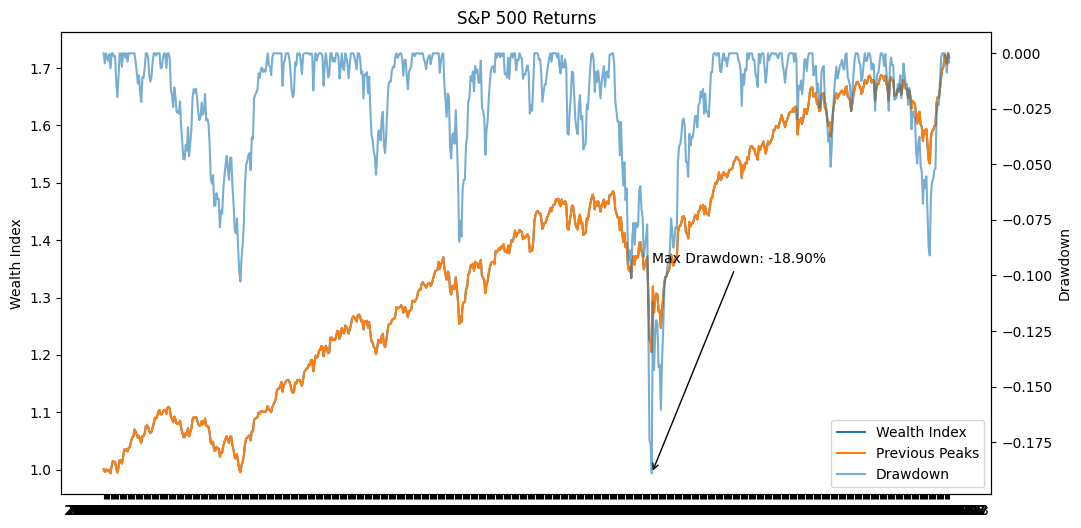

In [16]:
allReturnsSeries.append(sp500Return['^GSPC'])
maxDrawdownInfo.append(plotDrawdown(sp500Return['^GSPC'], title = "S&P 500 Returns"))
strategyName.append('S&P 500')

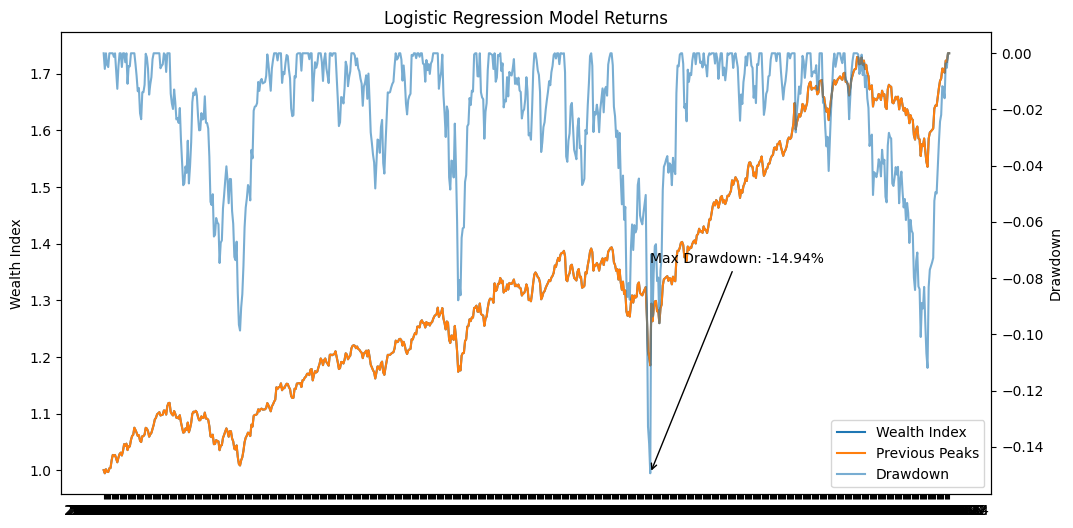

In [17]:
allReturnsSeries.append(LRdailyReturns)
maxDrawdownInfo.append(plotDrawdown(LRdailyReturns, title = 'Logistic Regression Model Returns'))
strategyName.append('Logistic Regression')

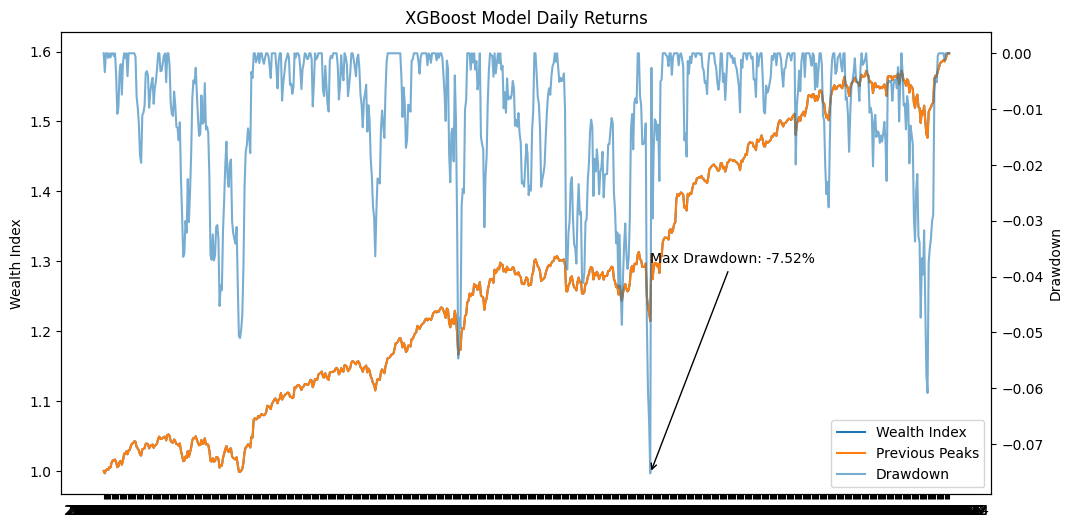

In [18]:
allReturnsSeries.append(XGdailyReturns)
maxDrawdownInfo.append(plotDrawdown(XGdailyReturns, title = 'XGBoost Model Daily Returns'))
strategyName.append('XGBoost')

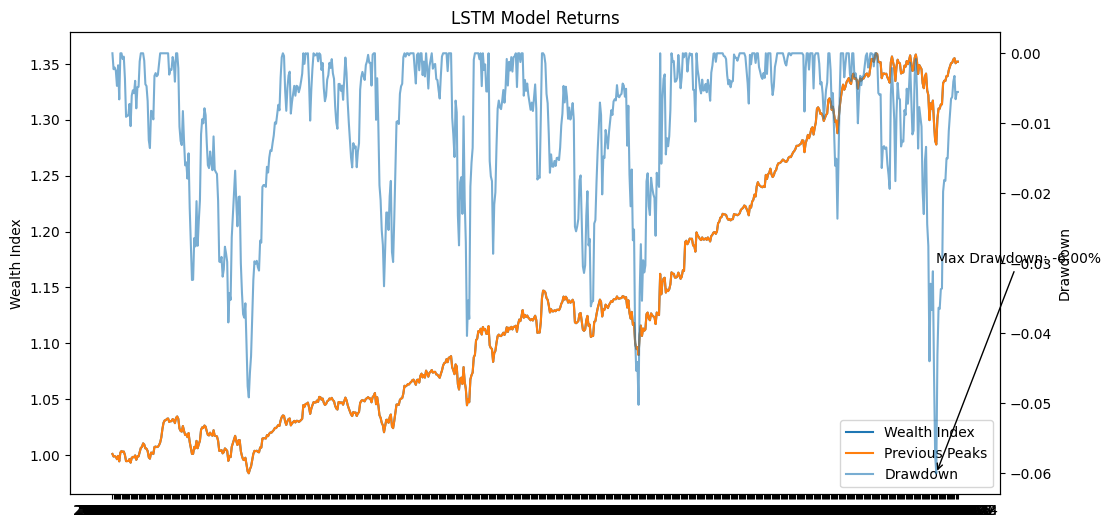

In [19]:
allReturnsSeries.append(LSTMdailyReturns)
maxDrawdownInfo.append(plotDrawdown(LSTMdailyReturns, 'LSTM Model Returns'))
strategyName.append('LSTM RNN')

In [20]:
LRprobabilities = pd.DataFrame(LRprobabilities)
XGProbabilities = pd.DataFrame(XGProbabilities)
LSTMProbs = pd.DataFrame(LSTMProbs)

avgProbs = (LRprobabilities + XGProbabilities + LSTMProbs) / 3
avgProbs = avgProbs.to_dict(orient='list')

avgTrades, AvgTradesAGG = getTrades(avgProbs)

avgDailyReturns = avgTrades.sum(axis=1) / AvgTradesAGG
avgDailyReturns = avgDailyReturns.fillna(0)

avgSharpeRatio = getSharpeRatio(avgDailyReturns.values)
avgSharpeRatio

np.float64(1.34602198540489)

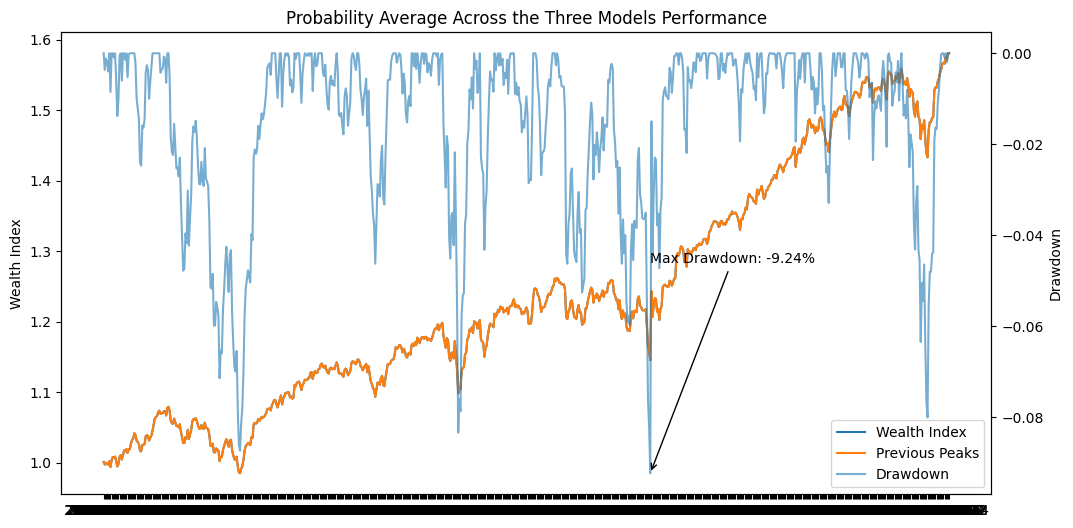

In [21]:
allReturnsSeries.append(avgDailyReturns)
maxDrawdownInfo.append(plotDrawdown(avgDailyReturns, title = 'Probability Average Across the Three Models Performance'))
strategyName.append('Average Across of all Three')

In [22]:
class BoldText:
    BOLD = '\033[1m'
    END = '\033[0m'

In [23]:
'''allReturnsSeries = []
maxDrawdownInfo = []
strategyName = []'''
import sys
for i in range(len(allReturnsSeries)):
    wealthIndex = 1 * (1 + allReturnsSeries[i]).cumprod()
    print(f'''The {BoldText.BOLD}{strategyName[i]}{BoldText.END} strategy yielded a {(100*(wealthIndex.iloc[-1] - wealthIndex.iloc[0]/wealthIndex.iloc[0])):.2f}% return. It had a max drawdown of {(maxDrawdownInfo[i]['Max Drawdown'] * 100):.2f}% on {maxDrawdownInfo[i]['Max Drawdown Date']}
It has a Sharpe Ratio of {getSharpeRatio(allReturnsSeries[i])} and a Sortino Ratio of {sortinoRatio(allReturnsSeries[i])} \n''')
    

The S&P 500 strategy yielded a 71.86% return. It had a max drawdown of -18.90% on 2025-04-08
It has a Sharpe Ratio of 1.3057488186929165 and a Sortino Ratio of 1.7396258461794754 

The Logistic Regression strategy yielded a 73.57% return. It had a max drawdown of -14.94% on 2025-04-07
It has a Sharpe Ratio of 1.3772434934506401 and a Sortino Ratio of 1.9025453913277508 

The XGBoost strategy yielded a 59.75% return. It had a max drawdown of -7.52% on 2025-04-07
It has a Sharpe Ratio of 1.5692822351447604 and a Sortino Ratio of 2.2511915068902097 

The LSTM RNN strategy yielded a 35.21% return. It had a max drawdown of -6.00% on 2026-03-27
It has a Sharpe Ratio of 1.4121833346634571 and a Sortino Ratio of 1.9922939134025424 

The Average Across of all Three strategy yielded a 58.08% return. It had a max drawdown of -9.24% on 2025-04-07
It has a Sharpe Ratio of 1.34602198540489 and a Sortino Ratio of 1.96769778705081 

